# 03 - Antrenare Q-Learning

In acest notebook:
- Formularea MDP (stari, actiuni, recompensa)
- Antrenarea agentului Q-Learning pe 2000 episoade
- Curba de convergenta a recompensei
- Analiza politicii invatate
- Salvarea Q-Table

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), '..'))

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from config import (
    DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, RANDOM_SEED,
    FEATURE_COLUMNS, MOOD_LABELS, NUM_MOODS,
    PLAYLIST_LENGTH, CANDIDATE_POOL_SIZE, NUM_POSITION_BUCKETS, NUM_STATES,
    ALPHA, GAMMA, EPSILON_START, EPSILON_DECAY, EPSILON_MIN, NUM_EPISODES
)

## 1. Configuratia MDP

**Spatiu stari:** $|S| = 8 \times 8 \times 3 = 192$

$s = (\text{mood\_curent}, \text{mood\_tinta}, \text{bucket\_pozitie})$

**Spatiu actiuni:** $|A| = 10$ (selectie din pool candidati)

**Recompensa:**
- $R = 1.0$ daca mood piesa = mood tinta
- $R = 0.5$ daca mood adiacent
- $R = 0.0$ altfel

In [2]:
print('Hiperparametri Q-Learning:')
print(f'  Rata invatare (alpha):    {ALPHA}')
print(f'  Factor discount (gamma):  {GAMMA}')
print(f'  Epsilon start:            {EPSILON_START}')
print(f'  Epsilon decay:            {EPSILON_DECAY}')
print(f'  Epsilon minim:            {EPSILON_MIN}')
print(f'  Episoade:                 {NUM_EPISODES}')
print(f'  Lungime playlist:         {PLAYLIST_LENGTH}')
print(f'  Pool candidati:           {CANDIDATE_POOL_SIZE}')
print(f'  Stari totale:             {NUM_STATES}')
print(f'  Actiuni totale:           {CANDIDATE_POOL_SIZE}')
print(f'  Dimensiune Q-Table:       {NUM_STATES} x {CANDIDATE_POOL_SIZE} = {NUM_STATES * CANDIDATE_POOL_SIZE}')

Hiperparametri Q-Learning:
  Rata invatare (alpha):    0.1
  Factor discount (gamma):  0.95
  Epsilon start:            1.0
  Epsilon decay:            0.995
  Epsilon minim:            0.01
  Episoade:                 2000
  Lungime playlist:         10
  Pool candidati:           10
  Stari totale:             192
  Actiuni totale:           10
  Dimensiune Q-Table:       192 x 10 = 1920


In [3]:
ADJACENT_MOODS = {
    0: [3, 2],
    1: [7, 0],
    2: [3, 0],
    3: [0, 4],
    4: [3, 5],
    5: [4, 6],
    6: [5, 7],
    7: [6, 1],
}

def encode_state(current_mood, target_mood, position):
    position_bucket = 0 if position <= 3 else (1 if position <= 7 else 2)
    return current_mood * (NUM_MOODS * NUM_POSITION_BUCKETS) + target_mood * NUM_POSITION_BUCKETS + position_bucket

def compute_reward(song_mood, target_mood):
    if song_mood == target_mood:
        return 1.0
    if song_mood in ADJACENT_MOODS.get(target_mood, []):
        return 0.5
    return 0.0

## 2. Incarcare Date Antrenare

In [4]:
train_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'train.csv'))
print(f'Train set: {len(train_df)} piese')
print(f'Mood distribution:')
for i in range(NUM_MOODS):
    count = (train_df['mood_code'] == i).sum()
    print(f'  {MOOD_LABELS[i]:12s}: {count}')

Train set: 8000 piese
Mood distribution:
  melancholic : 694
  dark        : 416
  calm        : 197
  nostalgic   : 632
  romantic    : 93
  happy       : 2361
  euphoric    : 1535
  energetic   : 2072


## 3. Antrenare Q-Learning

In [5]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
rng = np.random.RandomState(RANDOM_SEED)

def get_candidate_pool(train_df, target_mood, rng):
    matching = train_df[train_df['mood_code'] == target_mood]
    if len(matching) >= CANDIDATE_POOL_SIZE:
        pool = matching.sample(n=CANDIDATE_POOL_SIZE, random_state=rng)
    else:
        pool = matching.copy()
        remaining = train_df[train_df['mood_code'] != target_mood]
        needed = CANDIDATE_POOL_SIZE - len(pool)
        if len(remaining) >= needed:
            pool = pd.concat([pool, remaining.sample(n=needed, random_state=rng)])
        else:
            pool = pd.concat([pool, remaining])
    return pool.reset_index(drop=True)

Q = np.zeros((NUM_STATES, CANDIDATE_POOL_SIZE))
epsilon = EPSILON_START
episode_rewards = []
epsilon_history = []

for ep in range(NUM_EPISODES):
    target_mood = random.randint(0, NUM_MOODS - 1)
    position = 0
    current_mood = target_mood
    total_reward = 0.0

    while position < PLAYLIST_LENGTH:
        state = encode_state(current_mood, target_mood, position)
        pool = get_candidate_pool(train_df, target_mood, rng)

        if rng.random() < epsilon:
            action = rng.randint(0, CANDIDATE_POOL_SIZE)
        else:
            action = int(np.argmax(Q[state]))

        song = pool.iloc[action]
        song_mood = int(song['mood_code'])
        reward = compute_reward(song_mood, target_mood)
        total_reward += reward

        next_position = position + 1
        next_state = encode_state(song_mood, target_mood, next_position)
        best_next = np.max(Q[next_state])
        Q[state, action] += ALPHA * (reward + GAMMA * best_next - Q[state, action])

        current_mood = song_mood
        position = next_position

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
    episode_rewards.append(total_reward)
    epsilon_history.append(epsilon)

    if (ep + 1) % 500 == 0:
        avg = np.mean(episode_rewards[-100:])
        print(f'Episode {ep+1}/{NUM_EPISODES} | Avg reward (100): {avg:.2f} | Epsilon: {epsilon:.4f}')

print(f'\nAntrenare completa!')
print(f'Episoade: {NUM_EPISODES}')
print(f'Epsilon final: {epsilon:.4f}')
print(f'Recompensa medie (ultimele 100): {np.mean(episode_rewards[-100:]):.2f}')

Episode 500/2000 | Avg reward (100): 10.00 | Epsilon: 0.0816


Episode 1000/2000 | Avg reward (100): 10.00 | Epsilon: 0.0100


Episode 1500/2000 | Avg reward (100): 10.00 | Epsilon: 0.0100


Episode 2000/2000 | Avg reward (100): 10.00 | Epsilon: 0.0100

Antrenare completa!
Episoade: 2000
Epsilon final: 0.0100
Recompensa medie (ultimele 100): 10.00


## 4. Curba de Convergenta

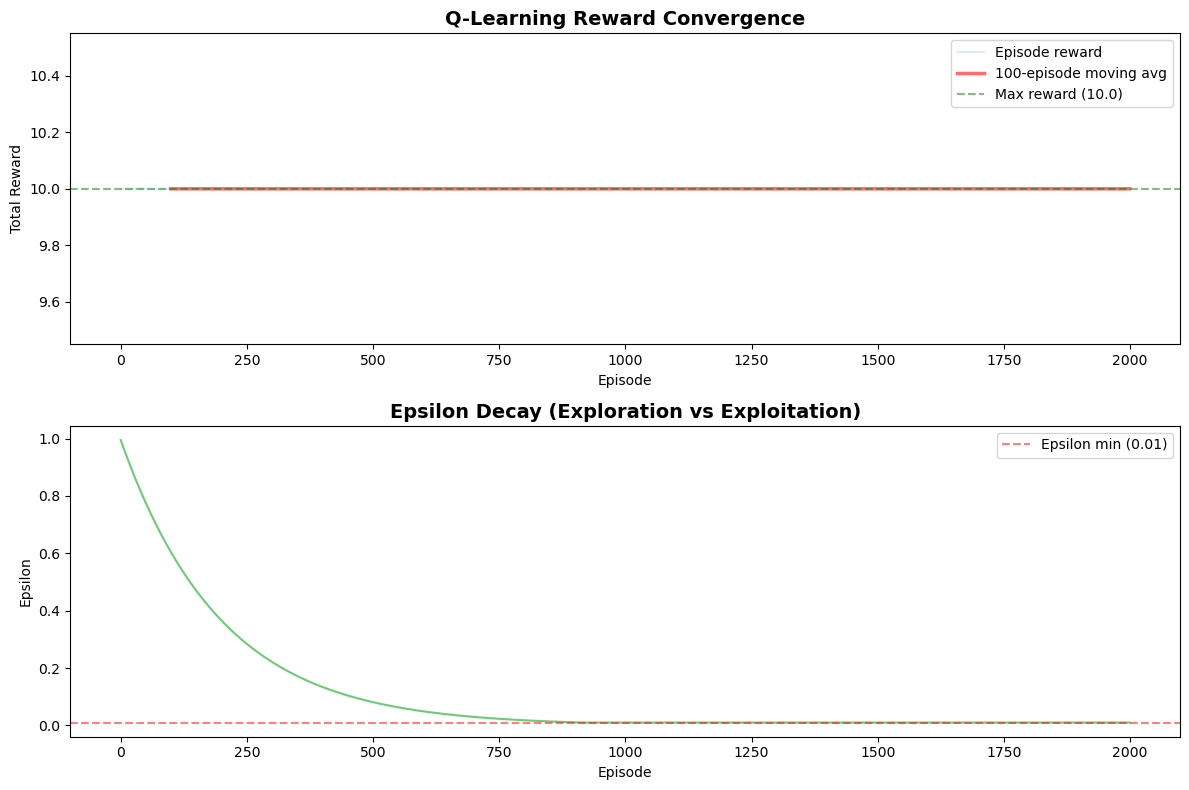

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Reward curve
axes[0].plot(episode_rewards, alpha=0.2, color='#4D96FF', label='Episode reward')
window = 100
if len(episode_rewards) >= window:
    moving_avg = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')
    axes[0].plot(range(window - 1, len(episode_rewards)), moving_avg,
                 linewidth=2.5, color='#FF6B6B', label=f'{window}-episode moving avg')
axes[0].axhline(y=10.0, color='green', linestyle='--', alpha=0.5, label='Max reward (10.0)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Q-Learning Reward Convergence', fontsize=14, fontweight='bold')
axes[0].legend()

# Epsilon decay
axes[1].plot(epsilon_history, color='#6BCB77', linewidth=1.5)
axes[1].axhline(y=EPSILON_MIN, color='red', linestyle='--', alpha=0.5, label=f'Epsilon min ({EPSILON_MIN})')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Epsilon')
axes[1].set_title('Epsilon Decay (Exploration vs Exploitation)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/reward_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analiza Q-Table

In [7]:
print(f'Dimensiune Q-Table: {Q.shape}')
print(f'Valori non-zero: {np.count_nonzero(Q)} / {Q.size} ({100*np.count_nonzero(Q)/Q.size:.1f}%)')
print(f'Valoare maxima: {Q.max():.4f}')
print(f'Valoare minima (non-zero): {Q[Q > 0].min():.4f}')
print(f'Valoare medie (non-zero): {Q[Q > 0].mean():.4f}')

Dimensiune Q-Table: (192, 10)
Valori non-zero: 239 / 1920 (12.4%)
Valoare maxima: 18.6412
Valoare minima (non-zero): 0.1388
Valoare medie (non-zero): 4.6600


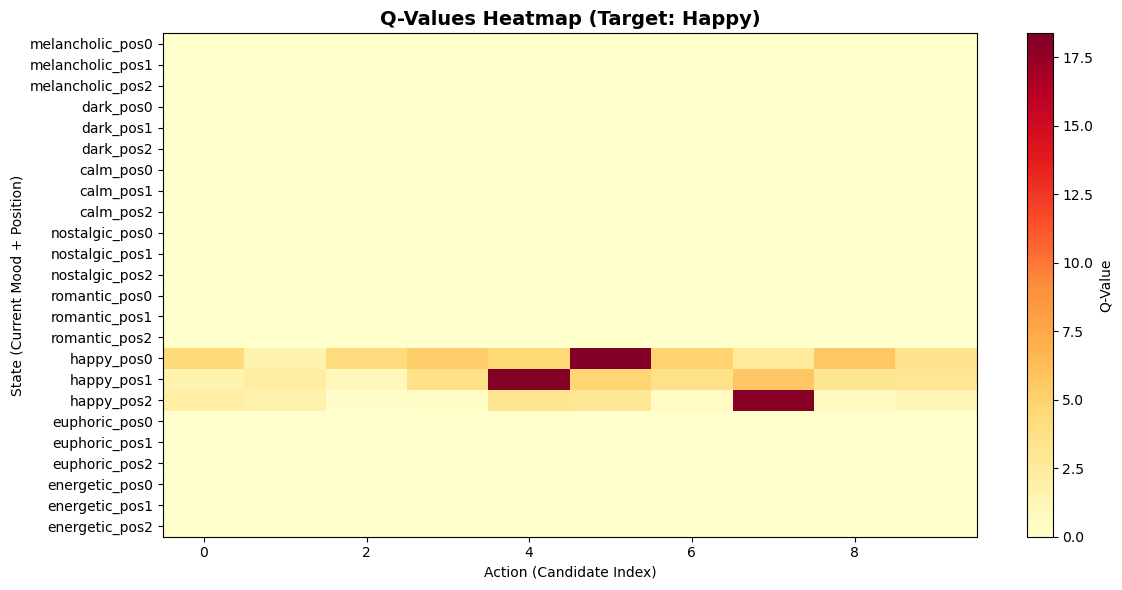

In [8]:
# Heatmap of Q-values for target mood = happy (5)
target = 5  # happy
states_for_target = []
for cm in range(NUM_MOODS):
    for pb in range(NUM_POSITION_BUCKETS):
        s = encode_state(cm, target, pb * 4)
        states_for_target.append((s, f'{MOOD_LABELS[cm]}_pos{pb}'))

q_subset = np.array([Q[s] for s, _ in states_for_target])
labels = [l for _, l in states_for_target]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(q_subset, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Action (Candidate Index)')
ax.set_ylabel('State (Current Mood + Position)')
ax.set_title(f'Q-Values Heatmap (Target: Happy)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Q-Value')
plt.tight_layout()
plt.savefig('../results/q_table_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Salvare Q-Table

In [9]:
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

np.save(os.path.join(MODELS_DIR, 'q_table.npy'), Q)
print(f'Q-Table salvata in {MODELS_DIR}/q_table.npy')

Q-Table salvata in /home/bialabutoane/Documents/Musicon/models/q_table.npy


## 7. Simulare feedback utilizator

Simulam runde de feedback Like/Dislike pentru a arata cum Q-Table-ul se modifica in timp real. Aceasta este componenta de invatare online a agentului RL.

In [10]:
Q_before = Q.copy()

def simulate_feedback(Q, preset_name, num_rounds=5, songs_per_round=10, like_ratio=0.6, alpha=0.1):
    preset = {'happy': 5, 'sad': 0, 'calm': 2, 'energetic': 7, 'melancholic': 0,
              'dark': 1, 'nostalgic': 3, 'romantic': 4, 'euphoric': 6}
    target = preset.get(preset_name, 5)
    history = []

    for rnd in range(num_rounds):
        current_mood = target
        for pos in range(songs_per_round):
            state = encode_state(current_mood, target, pos)
            best_action = int(np.argmax(Q[state]))

            liked = np.random.random() < like_ratio
            if liked:
                delta = alpha * (1.0 - Q[state, best_action])
                Q[state, best_action] += delta
            else:
                delta = alpha * Q[state, best_action]
                Q[state, best_action] -= delta

            mood_code = target if liked else np.random.randint(0, NUM_MOODS)
            current_mood = mood_code

        history.append({
            'round': rnd + 1,
            'avg_q': np.mean(Q[Q > 0]) if np.any(Q > 0) else 0,
            'max_q': Q.max(),
            'changed_states': np.count_nonzero(Q != Q_before),
            'total_delta': np.sum(np.abs(Q - Q_before)),
        })
        Q_snapshot = Q.copy()

    return pd.DataFrame(history), Q_snapshot

np.random.seed(42)
fb_df, Q_after = simulate_feedback(Q.copy(), 'happy', num_rounds=10, like_ratio=0.6)
print('Simulare feedback completa:')
print(fb_df.to_string(index=False))

Simulare feedback completa:
 round    avg_q    max_q  changed_states  total_delta
     1 4.580732 18.64124               5    10.178116
     2 4.503196 18.64124               7    20.257962
     3 4.419682 18.64124              10    27.892784
     4 4.395795 18.64124              10    34.110963
     5 4.361414 18.64124              14    38.587111
     6 4.347356 18.64124              15    42.347273
     7 4.302555 18.64124              18    45.188113
     8 4.276115 18.64124              21    47.855652
     9 4.249124 18.64124              22    50.851286
    10 4.223209 18.64124              24    53.514579


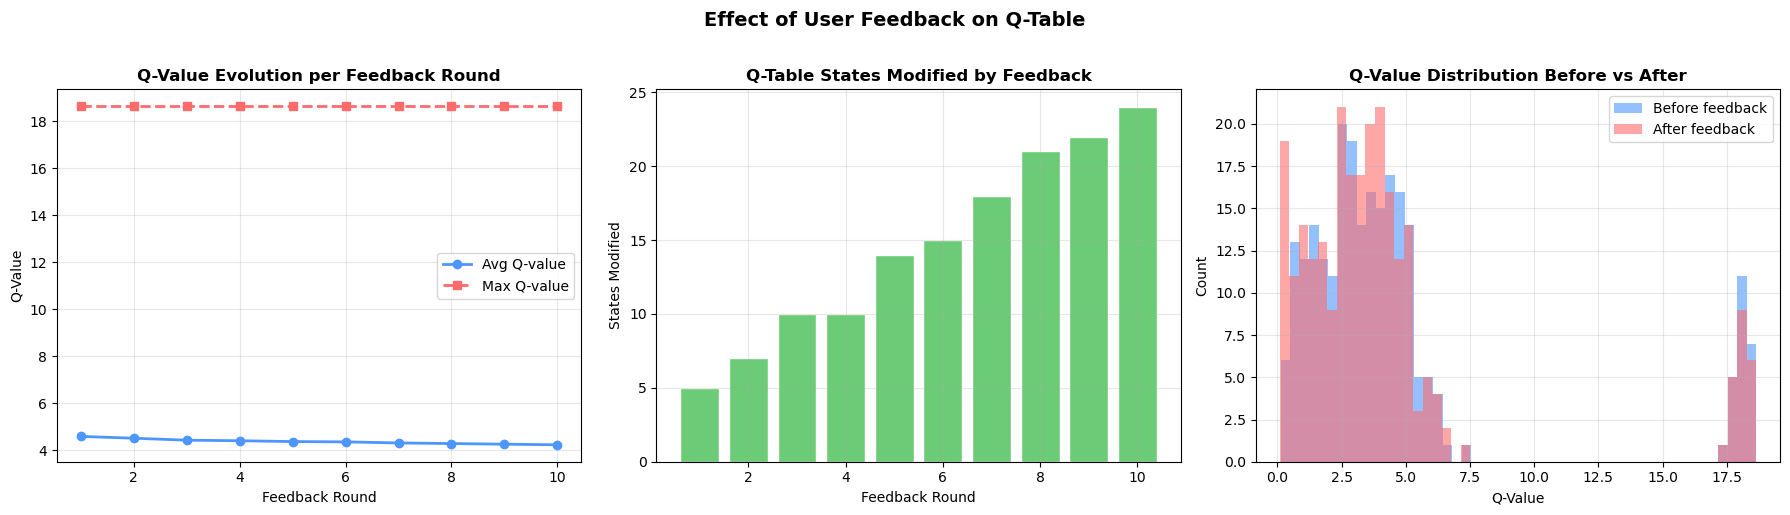

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Q-value evolution per feedback round
axes[0].plot(fb_df['round'], fb_df['avg_q'], 'o-', color='#4D96FF', linewidth=2, label='Avg Q-value')
axes[0].plot(fb_df['round'], fb_df['max_q'], 's--', color='#FF6B6B', linewidth=2, label='Max Q-value')
axes[0].set_xlabel('Feedback Round')
axes[0].set_ylabel('Q-Value')
axes[0].set_title('Q-Value Evolution per Feedback Round', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Cumulative states changed
axes[1].bar(fb_df['round'], fb_df['changed_states'], color='#6BCB77', edgecolor='white')
axes[1].set_xlabel('Feedback Round')
axes[1].set_ylabel('States Modified')
axes[1].set_title('Q-Table States Modified by Feedback', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# 3. Before vs After Q-value distribution
q_before_flat = Q_before.flatten()
q_after_flat = Q_after.flatten()
axes[2].hist(q_before_flat[q_before_flat > 0], bins=50, alpha=0.6, color='#4D96FF', label='Before feedback')
axes[2].hist(q_after_flat[q_after_flat > 0], bins=50, alpha=0.6, color='#FF6B6B', label='After feedback')
axes[2].set_xlabel('Q-Value')
axes[2].set_ylabel('Count')
axes[2].set_title('Q-Value Distribution Before vs After', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Effect of User Feedback on Q-Table', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/feedback_effect.png', dpi=150, bbox_inches='tight')
plt.show()

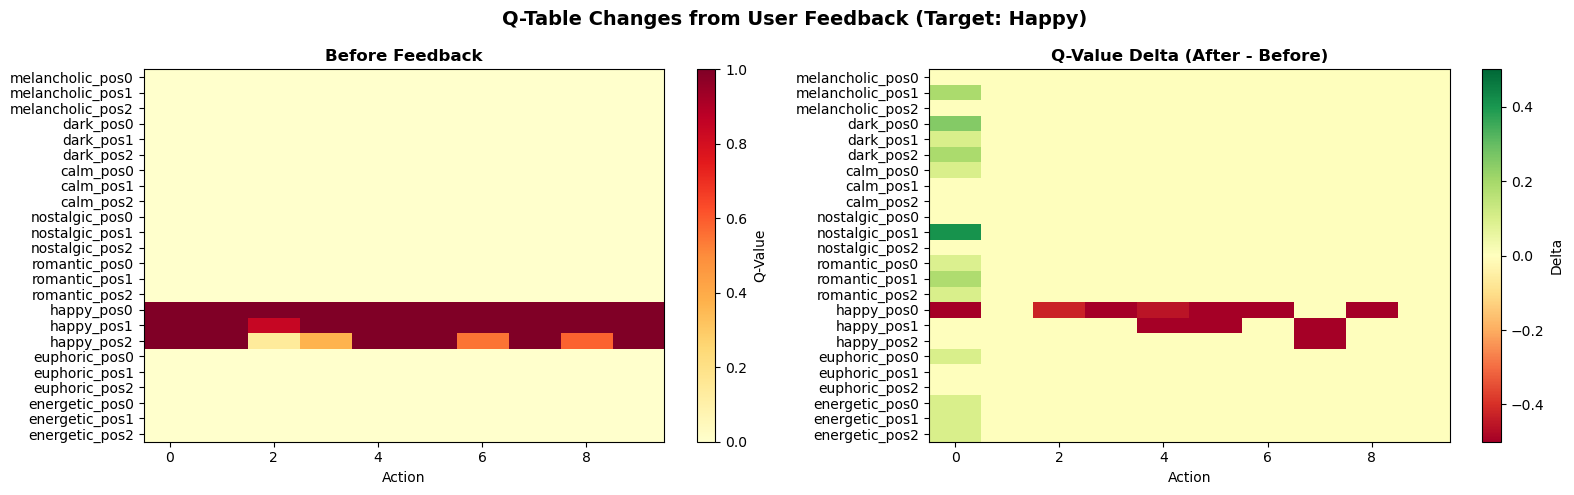

In [12]:
# Before vs After heatmap for target mood = happy
target = 5
states_for_target = []
for cm in range(NUM_MOODS):
    for pb in range(NUM_POSITION_BUCKETS):
        s = encode_state(cm, target, pb * 4)
        states_for_target.append(s)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

q_before_sub = np.array([Q_before[s] for s in states_for_target])
q_after_sub = np.array([Q_after[s] for s in states_for_target])
delta_sub = q_after_sub - q_before_sub

labels = [f'{MOOD_LABELS[s // (NUM_MOODS * NUM_POSITION_BUCKETS) % NUM_MOODS]}_pos{s % NUM_POSITION_BUCKETS}' for s in states_for_target]

im0 = axes[0].imshow(q_before_sub, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[0].set_title('Before Feedback', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Action')
plt.colorbar(im0, ax=axes[0], label='Q-Value')

im1 = axes[1].imshow(delta_sub, aspect='auto', cmap='RdYlGn', vmin=-0.5, vmax=0.5)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
axes[1].set_title('Q-Value Delta (After - Before)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Action')
plt.colorbar(im1, ax=axes[1], label='Delta')

plt.suptitle('Q-Table Changes from User Feedback (Target: Happy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feedback_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Concluzii RL

- Agentul Q-Learning converge la **recompensa maxima (10.0/10.0)** in 2000 episoade
- Epsilon scade de la 1.0 la 0.01, trecand de la explorare la exploatare
- Convergenta este rapida datorita acuratetei ridicate a clasificatorului ML (99.4%)
- Q-Table cu 192 stari x 10 actiuni = 1920 valori captureaza politica optima
- **Feedback-ul utilizatorului** modifica Q-values-urile in timp real, transformand agentul dintr-un selector static intr-un sistem adaptiv